In [1]:
import pandas as pd
import os
import json
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.ticker import MultipleLocator
import networkx as nx
from scipy.stats import zscore
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import fdrcorrection
import math

In [ ]:
plt.rcParams['svg.fonttype'] = 'none'

## Load data

In [3]:
gnpc_hc = pd.read_csv('./data/GNPC_HC_clinical.csv')

In [5]:
pl_meta_sex_idx = pd.read_csv("./results/gnpc_meta_sex_idx_update.csv")
cell_type_performance = pd.read_csv("./results/Rev_UPDATE_cell_type_performance_gnpc_update_0912.csv")
df_age_gap = pd.read_csv("./results/Rev_UPDATE_gnpc_cell_type_gaps_z_v3.3_by_COHORT_HC_across_cohorts_z.csv")

In [6]:
pl_meta_sex_idx['hc'] = pl_meta_sex_idx['sample_id'].isin(gnpc_hc['sample_id']).astype(int)

In [8]:
hc_age_gap = df_age_gap[df_age_gap['sample_id'].isin(gnpc_hc['sample_id'])]
hc_age_gap.shape

(7074, 79)

Remove low-performing cell types and sex-specific cell types

In [9]:
drop_1=["Spermatogonia", "Late spermatids", 
          "Early spermatids",  "Spermatocytes", 
          "Oocytes", "Syncytiotrophoblasts", 
          "Extravillous trophoblasts", 
          "Cytotrophoblasts",
          "Peritubular cells",
          "Sertoli cells",
          "Prostatic glandular cells"]

drop_2 = ["Breast myoepithelial cells",
"Ductal cells", "Ovarian stromal cells", "Leydig cells", "Basal squamous epithelial cells",
"Salivary duct cells", "Basal keratinocytes", "Collecting duct cells",
"Endometrial stromal cells", "Basal prostatic cells", "Granulosa cells", "Cytotrophoblasts",
"Secretory cells", "Rod photoreceptor cells", "Glandular and luminal cells",
"Squamous epithelial cells", "Cone photoreceptor cells", "Distal enterocytes",
"Club cells", "Paneth cells", "Ionocytes", "Cholangiocytes", "Melanocytes"]

In [10]:
low_performing_cells = cell_type_performance[cell_type_performance['evaluation_gnpc'] < 0.15]
low_performing_cell_types = low_performing_cells['cell_type'].tolist()
low_performing_cell_types = [cell_type.replace(" ", ".") for cell_type in low_performing_cells['cell_type'].tolist()]
print("Cell types with evaluation_gnpc < 0.15:", low_performing_cell_types)

Cell types with evaluation_gnpc < 0.15: ['Basal.keratinocytes', 'Basal.prostatic.cells', 'Basal.squamous.epithelial.cells', 'Bipolar.cells', 'Breast.myoepithelial.cells', 'Collecting.duct.cells', 'Distal.enterocytes', 'Ductal.cells', 'Endometrial.stromal.cells', 'Granulosa.cells', 'Ionocytes', 'Leydig.cells', 'Melanocytes', 'Ovarian.stromal.cells', 'Secretory.cells', 'Squamous.epithelial.cells']


In [11]:
import re
low_performing_cell_types = [re.sub(r"\.", " ", cell_type) for cell_type in low_performing_cell_types]

In [12]:
unique_low_performers = [cell_type for cell_type in low_performing_cell_types 
                        if cell_type not in drop_1 and cell_type not in drop_2]
unique_low_performers

['Bipolar cells']

In [13]:
columns_to_drop = drop_1 + drop_2 + unique_low_performers + ['sample_id']
age_gap_df = hc_age_gap.drop(columns=columns_to_drop)
age_gap_df.head()

,Chronological_Age,Adipocytes,Alveolar cells type 1,Alveolar cells type 2,Astrocytes,B cells,Basal respiratory cells,Breast glandular cells,Cardiomyocytes,Ciliated cells,...,Proximal tubular cells,Schwann cells,Serous glandular cells,Skeletal myocytes,Smooth muscle cells,Suprabasal keratinocytes,T cells,dendritic cells,granulocytes,monocytes
1,65,0.759192,-0.073912,0.761840,0.514613,-0.668403,0.006805,-0.331339,0.017225,-1.752482,...,-0.175468,-0.928225,-0.452130,0.088308,2.446099,-0.588049,0.091182,0.472148,0.434692,0.246752
2,72,1.833792,0.314897,1.597285,-0.799942,-0.277941,-0.056882,0.218156,-0.096676,-1.036977,...,-0.601175,-0.662575,0.499606,-0.651022,-0.218070,-0.101160,-0.874203,0.605767,-1.071982,-0.362439
5,80,0.819967,-5.490629,0.716713,1.141838,0.400804,1.028245,-0.198305,1.052800,-0.214558,...,-1.244850,0.942028,-0.576286,-0.586412,0.442004,-0.372581,1.234066,0.511962,-0.500286,1.894979
9,78,1.041445,0.715669,1.242697,1.138101,0.859935,0.634681,-0.897897,2.493920,0.603018,...,0.307808,3.325770,-0.157859,0.784732,-0.228157,1.263977,-0.556930,0.806115,0.936812,0.690813
10,62,-1.000159,-0.727292,-2.147206,-1.570115,-0.784073,0.296854,0.925252,-1.386490,0.181870,...,0.204992,-0.624732,0.135507,0.044310,-2.182121,0.737654,-0.723607,-1.793439,-0.504358,0.116866


## Identify extreme agers

In [14]:
extreme_ager = pd.DataFrame(0, 
                           index=age_gap_df.index, 
                           columns=age_gap_df.columns[1:])  # Exclude the last column
extreme_ager[age_gap_df.iloc[:, 1:] >= 2] = 1  # Exclude the last column
extreme_ager[age_gap_df.iloc[:, 1:] <= -2] = -1  # Exclude the last column
extreme_ager['Age'] = age_gap_df['Chronological_Age']
extreme_ager.head(10)

,Adipocytes,Alveolar cells type 1,Alveolar cells type 2,Astrocytes,B cells,Basal respiratory cells,Breast glandular cells,Cardiomyocytes,Ciliated cells,Distal tubular cells,...,Schwann cells,Serous glandular cells,Skeletal myocytes,Smooth muscle cells,Suprabasal keratinocytes,T cells,dendritic cells,granulocytes,monocytes,Age
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,65
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,72
5,0,-1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,80
9,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,78
10,0,0,-1,0,0,0,0,0,0,0,...,0,0,0,-1,0,0,0,0,0,62
14,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,64
19,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,77
25,0,0,0,0,-1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,71
26,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,76
27,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,74


In [16]:
# First, identify all columns except 'Age'
cell_type_cols = [col for col in extreme_ager.columns if col != 'Age']

# Find rows with exactly one value of 1
rows_with_one_positive = (extreme_ager[cell_type_cols] == 1).sum(axis=1) == 1

# Count how many people meet this condition
count_one_positive = rows_with_one_positive.sum()

print(f"Number of people with exactly one value of 1 across all cell types: {count_one_positive}")

count_one_positive / extreme_ager.shape[0]

Number of people with exactly one value of 1 across all cell types: 1723


0.24356799547639243

In [17]:
# Find rows with no extreme aging (all values are 0)
no_extreme_aging = (extreme_ager[cell_type_cols] == 0).all(axis=1)

# Count and calculate percentage
count_no_extreme = no_extreme_aging.sum()
total_people = extreme_ager.shape[0]
percentage_no_extreme = (count_no_extreme / total_people) * 100

print(f"People with no extreme aging: {count_no_extreme} out of {total_people}")
print(f"Percentage with no extreme aging: {percentage_no_extreme:.2f}%")

People with no extreme aging: 2504 out of 7074
Percentage with no extreme aging: 35.40%


In [18]:
rows_with_more_positive = (extreme_ager[cell_type_cols] == 1).sum(axis=1) >= 10

count_more_positive = rows_with_more_positive.sum()

count_more_positive / extreme_ager.shape[0]

0.014560361888606163

## Visualize extreme aging distribution

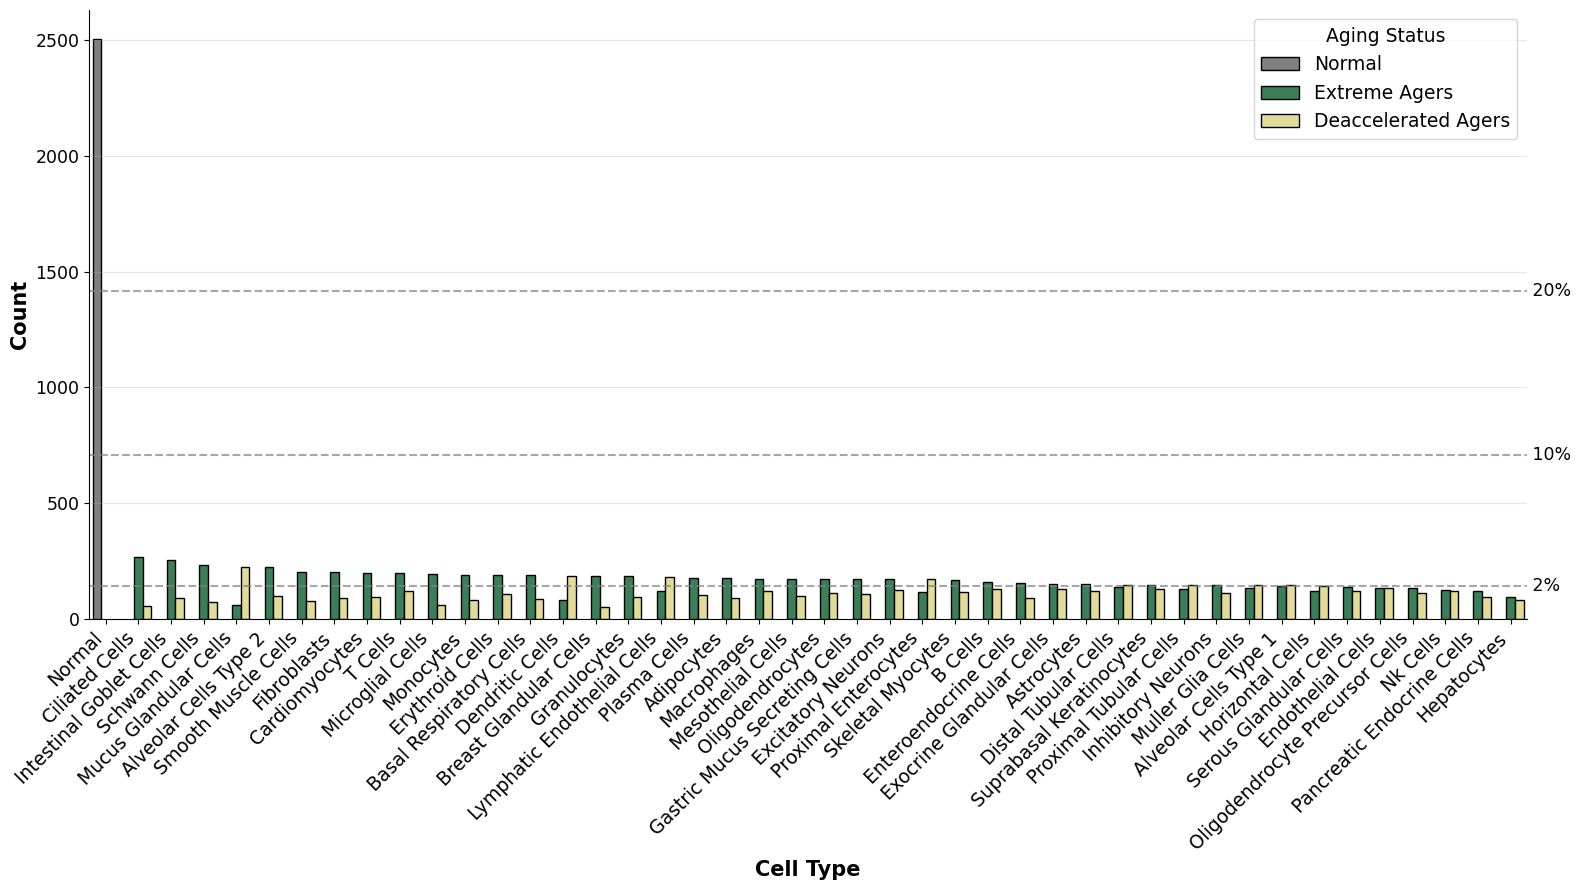

                  Cell Type  Count                 Type    Percent  \
0                    Normal   2504               Normal  35.397229   
17           Ciliated Cells    268        Extreme Agers   3.788521   
41  Intestinal Goblet Cells    257        Extreme Agers   3.633022   
69            Schwann Cells    234        Extreme Agers   3.307888   
52    Mucus Glandular Cells    225  Deaccelerated Agers   3.180662   
..                      ...    ...                  ...        ...   
70            Schwann Cells     72  Deaccelerated Agers   1.017812   
51    Mucus Glandular Cells     62        Extreme Agers   0.876449   
50         Microglial Cells     61  Deaccelerated Agers   0.862313   
18           Ciliated Cells     58  Deaccelerated Agers   0.819904   
14   Breast Glandular Cells     52  Deaccelerated Agers   0.735086   

                   Original  
0                       NaN  
17           Ciliated cells  
41  Intestinal goblet cells  
69            Schwann cells  
52    Muc

In [ ]:
def plot_extreme_ager_counts(extreme_ager_df):
    # Get list of cell type columns (all columns except 'Age')
    cell_types = [col for col in extreme_ager_df.columns if col != 'Age']
    
    # Count normal individuals (no extreme values in any cell type)
    no_extreme_values = (extreme_ager_df[cell_types] == 0).all(axis=1).sum()
    
    # Calculate counts for each cell type
    counts_data = []
    
    # First add the count of individuals with no extreme values
    counts_data.append({
        'Cell Type': 'Normal',
        'Count': no_extreme_values,
        'Type': 'Normal',
        'Percent': 100 * no_extreme_values / len(extreme_ager_df)
    })
    
    # Then add counts for each cell type
    for cell_type in cell_types:
        # Format cell type name by replacing dots with spaces
        formatted_cell_type = cell_type.replace('.', ' ').title()

        
        # Count accelerated agers
        acc_count = (extreme_ager_df[cell_type] == 1).sum()
        if acc_count > 0:
            counts_data.append({
                'Cell Type': formatted_cell_type,
                'Original': cell_type,
                'Count': acc_count,
                'Type': 'Extreme Agers',
                'Percent': 100 * acc_count / len(extreme_ager_df)
            })
        
        # Count decelerated agers
        dec_count = (extreme_ager_df[cell_type] == -1).sum()
        if dec_count > 0:
            counts_data.append({
                'Cell Type': formatted_cell_type,
                'Original': cell_type,
                'Count': dec_count,
                'Type': 'Deaccelerated Agers',
                'Percent': 100 * dec_count / len(extreme_ager_df)
            })
    
    counts_df = pd.DataFrame(counts_data)
    
    counts_df = counts_df.sort_values('Count', ascending=False)
    
    # Create a categorical type with the sorted order for cell types
    ordered_cell_types = ['Normal'] + [ct for ct in counts_df['Cell Type'].unique() if ct != 'Normal']
    counts_df['Cell Type'] = pd.Categorical(
        counts_df['Cell Type'], 
        categories=ordered_cell_types,
        ordered=True
    )
    
    plt.figure(figsize=(16, 9), facecolor='white')
    
    sns.reset_orig()
    
    color_map = {'Normal': 'grey', 'Extreme Agers': 'seagreen', 'Deaccelerated Agers': 'khaki'}
    
    # Create bar plot
    ax = sns.barplot(x='Cell Type', y='Count', hue='Type', data=counts_df,
                    palette=color_map, edgecolor='black')
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add 2%, 10%, and 20% threshold lines
    total_samples = len(extreme_ager_df)
    thresholds = [2, 10, 20]
    for threshold in thresholds:
        line_y = threshold * total_samples / 100
        plt.axhline(y=line_y, color='gray', linestyle='--', alpha=0.7)
        plt.text(len(ordered_cell_types) - 0.5, line_y, f" {threshold}%", va='center', fontsize=12.5)
    
    ax.set_facecolor('white')
    
    plt.xticks(rotation=45, ha='right', fontsize=13.5)
    plt.yticks(fontsize=12.5)
    
    plt.xlabel('Cell Type', fontsize=15, fontweight='bold')
    plt.ylabel('Count', fontsize=15, fontweight='bold')
    plt.legend(title='Aging Status', fontsize=13.5, title_fontsize=13.5)
    
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    filename = './Rev_results/supp_extreme_aging_dist'  
    plt.show()
    
    return counts_df

counts_summary = plot_extreme_ager_counts(extreme_ager)
print(counts_summary)

## 

In [21]:
# load cell_type.csv
cell_type_df = pd.read_csv('cell_type.csv')
cell_type_df = cell_type_df.replace(r'\\$', '', regex=True)
for column in cell_type_df.columns:
    cell_type_df[column] = cell_type_df[column].astype(str).str.replace(' ', '.')  # Replace spaces with periods
    cell_type_df[column] = cell_type_df[column].astype(str).str.replace('-', '.')  # Replace hyphens with periods
cell_type_df = cell_type_df.replace("Alveolar.cells.type", "Alveolar.cells.type.1")
cell_type_df.head()

columns = cell_type_df.columns

categories = {}
for index, row in cell_type_df.iterrows():
    cell = row[columns[0]]
    category = row[columns[1]]
    
    if category not in categories:
        categories[category] = []
    
    categories[category].append(cell)
    
category_order = ["Neuronal.cells", "Glial.cells",
                 "Blood.&.immune.cells", "Muscle.cells",  
                 "Mesenchymal.cells", "Adipocytes", 
                 "Specialized.epithelial.cells",
                 "Glandular.epithelial.cells", "Endothelial.cells",
                 "Endocrine.cells"]

In [25]:
def analyze_age_stratified_extreme_agers(extreme_ager_df):
    # Define age brackets in the order we want them to appear
    age_brackets = [
        ("< 60", 0, 60),
        ("60-70", 60, 70),
        ("70-80", 70, 80),
        ("80-85", 80, 85),
        ("> 85", 85, float('inf'))
    ]
    
    # Get list of cell type columns (all columns except 'Age')
    cell_types = [col for col in extreme_ager_df.columns if col != 'Age']
    
    # Create a dictionary to store results for each cell type and age bracket
    results = {}
    
    # Dictionary to store total patients in each bracket
    bracket_totals = {}
    
    # Process each age bracket
    for bracket_name, min_age, max_age in age_brackets:
        # Filter data for this age bracket
        bracket_df = extreme_ager_df[(extreme_ager_df['Age'] >= min_age) & (extreme_ager_df['Age'] < max_age)]
        
        # Skip if no data in this bracket
        if len(bracket_df) == 0:
            continue
            
        # Store total patients in this bracket
        total_in_bracket = len(bracket_df)
        bracket_totals[bracket_name] = total_in_bracket
        
        # Process each cell type
        for cell_type in cell_types:
            # Format cell type name
            formatted_cell_type = cell_type.replace('.', ' ').title()
            
            # Count individuals in each category
            normal_count = (bracket_df[cell_type] == 0).sum()
            accelerated_count = (bracket_df[cell_type] == 1).sum()
            decelerated_count = (bracket_df[cell_type] == -1).sum()
            
            # Calculate percentages
            normal_pct = 100 * normal_count / total_in_bracket
            accelerated_pct = 100 * accelerated_count / total_in_bracket
            decelerated_pct = 100 * decelerated_count / total_in_bracket
            
            # Add to results
            if formatted_cell_type not in results:
                results[formatted_cell_type] = []
                
            results[formatted_cell_type].append({
                'Age Bracket': bracket_name,
                'Normal Count': normal_count,
                'Normal %': normal_pct,
                'Accelerated Count': accelerated_count,
                'Accelerated %': accelerated_pct,
                'Decelerated Count': decelerated_count,
                'Decelerated %': decelerated_pct,
                'Total': total_in_bracket
            })
    
    return results, bracket_totals

In [ ]:
plt.rcParams.update({
    'font.size': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7
})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['svg.fonttype'] = 'none'

In [27]:
results, bracket_totals = analyze_age_stratified_extreme_agers(extreme_ager)

/tmp/ipykernel_152/788273460.py:79: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = pivot_df.applymap(annot_formatter)


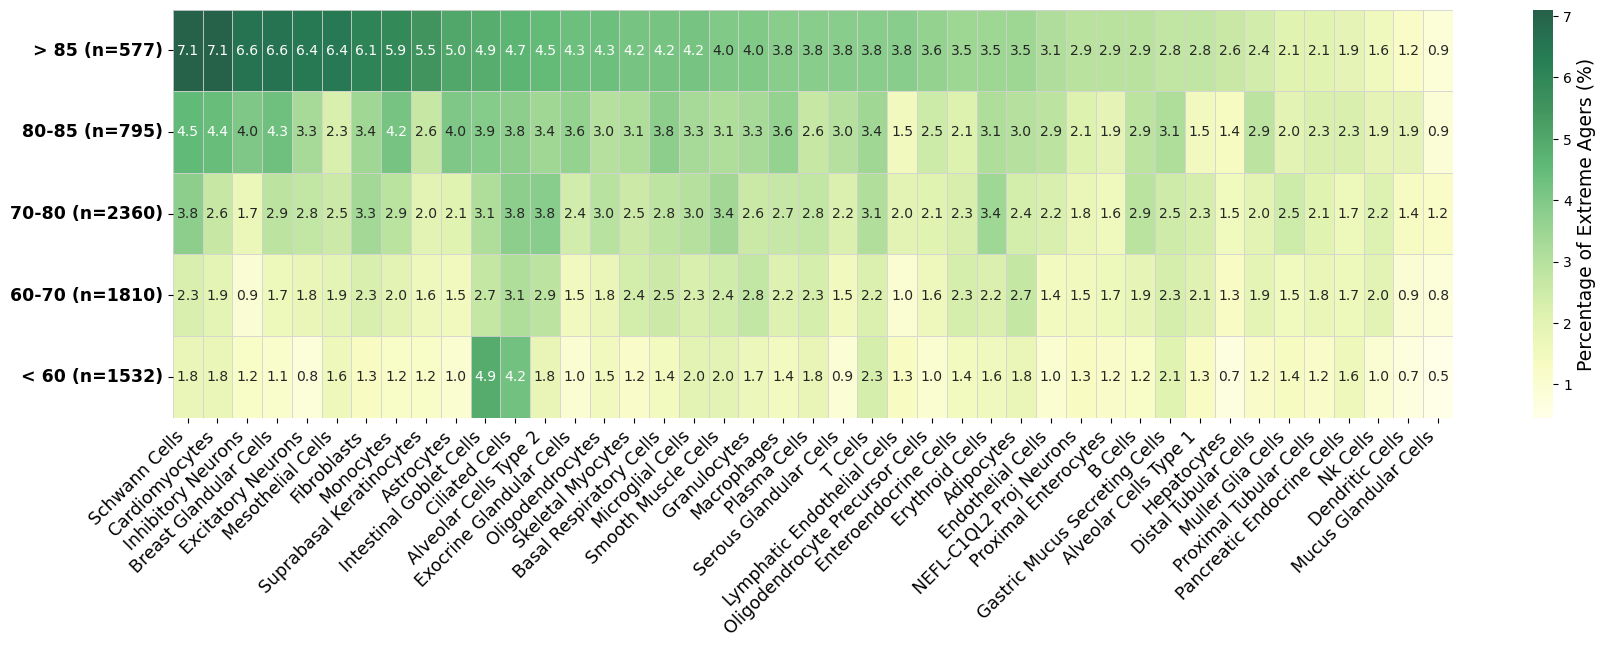

In [ ]:
# Create a heatmap showing the percentage of extreme agers by cell type and age bracket
def create_extreme_ager_heatmap(results, bracket_totals):
    plt.rcParams['svg.fonttype'] = 'none' 
    plt.rcParams['font.family'] = 'Arial'
    
    # Prepare data for heatmap
    heatmap_data = []
    
    for cell_type, data in results.items():
        for entry in data:
            heatmap_data.append({
                'Cell Type': cell_type,
                'Age Bracket': entry['Age Bracket'],
                'Extreme Agers %': entry['Accelerated %']
            })
    
    # Convert to DataFrame
    heatmap_df = pd.DataFrame(heatmap_data)
    heatmap_df['Cell Type'] = heatmap_df['Cell Type'].replace('Horizontal Cells', 'NEFL-C1QL2 Proj Neurons')
    
    
    # Define the correct order for age brackets - now reversed to put older first
    age_bracket_order = ["> 85", "80-85", "70-80",  "60-70",  "< 60"]

    
    # Filter to only include brackets that exist in our data
    existing_brackets = heatmap_df['Age Bracket'].unique()
    ordered_brackets = [bracket for bracket in age_bracket_order if bracket in existing_brackets]
    
    # Pivot for heatmap format - now with age brackets as rows and cell types as columns
    pivot_df = heatmap_df.pivot(index='Age Bracket', columns='Cell Type', values='Extreme Agers %')
    
    # Order age brackets with oldest at top
    pivot_df = pivot_df.reindex(ordered_brackets)
    
    custom_cell_type_order = [
        "Schwann Cells", 
        "Cardiomyocytes", 
        "Inhibitory Neurons", 
        "Breast Glandular Cells",
        "Excitatory Neurons", 
        "Mesothelial Cells",
        "Fibroblasts"]
    
    all_cell_types = pivot_df.columns.tolist()
    
    if "> 85" in pivot_df.index:
        oldest_bracket_values = pivot_df.loc["> 85"]
        sorted_all_cell_types = oldest_bracket_values.sort_values(ascending=False).index.tolist()
    else:
        sorted_all_cell_types = all_cell_types
    
    # Extract the specified cell types from the sorted list
    priority_cell_types = [ct for ct in custom_cell_type_order if ct in all_cell_types]
    
    # Remove the priority cell types from the sorted list
    remaining_cell_types = [ct for ct in sorted_all_cell_types if ct not in priority_cell_types]
    
    # Combine the lists: first the priority types in custom order, then the rest in sorted order
    ordered_cell_types = priority_cell_types + remaining_cell_types
    
    # Reorder columns based on the final ordered cell types
    pivot_df = pivot_df[ordered_cell_types]
    
    # Create the heatmap with adjusted dimensions for many columns
    plt.figure(figsize=(20, 6), facecolor='white')
    sns.reset_orig()
    
    # Create annotation formatter to handle NaN values
    def annot_formatter(val):
        if np.isnan(val):
            return ""
        return f"{val:.1f}"
    
    # Create annotations matrix
    annot = pivot_df.applymap(annot_formatter)
    
    ax = sns.heatmap(pivot_df, cmap='YlGn', annot=annot, fmt="", 
                   linewidths=0.5, linecolor='lightgrey', alpha=0.85,
                   cbar_kws={'label': 'Percentage of Extreme Agers (%)'})
    
    plt.ylabel('', fontsize=15, fontweight='bold')
    plt.xlabel('', fontsize=15, fontweight='bold')
    cbar = ax.collections[0].colorbar
    cbar.ax.set_ylabel('Percentage of Extreme Agers (%)', fontsize=13.5)
    
    # Add patient counts to row labels
    new_row_labels = [f"{bracket} (n={bracket_totals[bracket]})" for bracket in ordered_brackets]
    ax.set_yticklabels(new_row_labels, fontsize=12.5, rotation=0, fontweight='bold')
    
    # Rotate column labels 45 degrees
    plt.xticks(rotation=45, ha='right', fontsize=12.5)
    
    # Adjust margins to ensure labels fit properly
    plt.subplots_adjust(left=0.1, bottom=0.2)
    
    plt.savefig('./Rev_results/extreme_ager_heatmap.png', dpi=300, bbox_inches='tight')
    plt.savefig('./Rev_results/extreme_ager_heatmap.svg', dpi=300, bbox_inches='tight', format='svg')
    plt.savefig('./Rev_results/extreme_ager_heatmap.pdf', dpi=300, bbox_inches='tight', format='pdf')
    plt.show()

create_extreme_ager_heatmap(results, bracket_totals)

In [172]:
age_gap_df.to_csv('./results/age_gap_for_visualization.csv')